# Olympus adaptive-batching reproducibility

This notebook reproduces the final adaptive-batching analysis for tidyHEBO on the 19 Olympus tasks. Adaptive caps of 2, 4, 8, and 16 are compared with the sequential tidyHEBO baseline.

The analysis uses both the objective traces (`tidyhebo_values.txt`) and the recorded number of candidates returned at each feedback round (`tidyhebo_n_from_opt.txt`). The first four initialization evaluations follow the historical treatment used for the manuscript analysis; later candidates update the incumbent only when their adaptive batch is complete.

## Re-run the adaptive experiments

After creating the environments from [`README.md`](README.md), a single task/cap setting can be reproduced with:

```bash
conda run -n tidyhebo python olympus_run/orchestrator.py \
  --dataset agnp --optimizer tidyhebo \
  --num-iterations 100 --num-runs 30 \
  --adaptive-ceil 4 \
  --output-dir reproduced_results/olympus_adaptive
```

Repeat for all 19 Olympus tasks and `--adaptive-ceil 2`, `4`, `8`, and `16`. The orchestrator creates `adaptive_bs_<cap>/` below the selected output directory. Output files are append-only, so use an empty directory for a fresh reproduction.

The cells below analyze the archived manuscript data in `03_olympus_adaptive_batching/` against the sequential baseline in `02_olympus/`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt

from reproducibility.adaptive_batching import (
    build_adaptive_summary,
    cross_task_summary,
)

ROOT = Path.cwd()
SEQUENTIAL_ROOT = ROOT / "02_olympus"
ADAPTIVE_ROOT = ROOT / "03_olympus_adaptive_batching"
CONFIGS_ROOT = ROOT / "olympus_run" / "configs" / "tasks"

task_level = build_adaptive_summary(SEQUENTIAL_ROOT, ADAPTIVE_ROOT, CONFIGS_ROOT)
assert task_level.shape[0] == 19 * 4, task_level.shape
print("Validated 19 tasks × 4 adaptive caps.")

Validated 19 tasks × 4 adaptive caps.


## Cross-task summary

Performance is expressed as an adaptive/sequential ratio, so 1.0 is the sequential tidyHEBO baseline and lower values are better. Feedback reduction is the fraction of the 100 sequential feedback opportunities avoided by the adaptive schedule.

In [2]:
summary = cross_task_summary(task_level)
summary[
    [
        "cap",
        "median_feedback_reduction",
        "median_nAUC_ratio",
        "CVaR_nAUC_ratio",
        "IQR_nAUC_ratio",
    ]
].assign(
    median_feedback_reduction=lambda frame: 100 * frame["median_feedback_reduction"]
).rename(columns={"median_feedback_reduction": "median_feedback_reduction_%"}).round(3)

,cap,median_feedback_reduction_%,median_nAUC_ratio,CVaR_nAUC_ratio,IQR_nAUC_ratio
0,2,32.567,1.104,1.219,1.409
1,4,46.367,1.150,1.256,1.603
2,8,56.467,1.330,1.430,1.804
3,16,68.000,1.548,1.823,2.619


## Final adaptive-batching figure

Panels **A–C** show task-level trade-offs between feedback-round reduction and relative median nAUC (**A**), CVaR nAUC (**B**), and IQR nAUC (**C**). Colored dashed lines mark cross-task medians for each cap; the horizontal dotted line is the sequential baseline. Black downward triangles mark observations above the plotted y-range and are labeled with their true ratio. Panel **D** summarizes the cross-task median ratios with grouped bars, ordered as Quality, CVaR, and IQR.

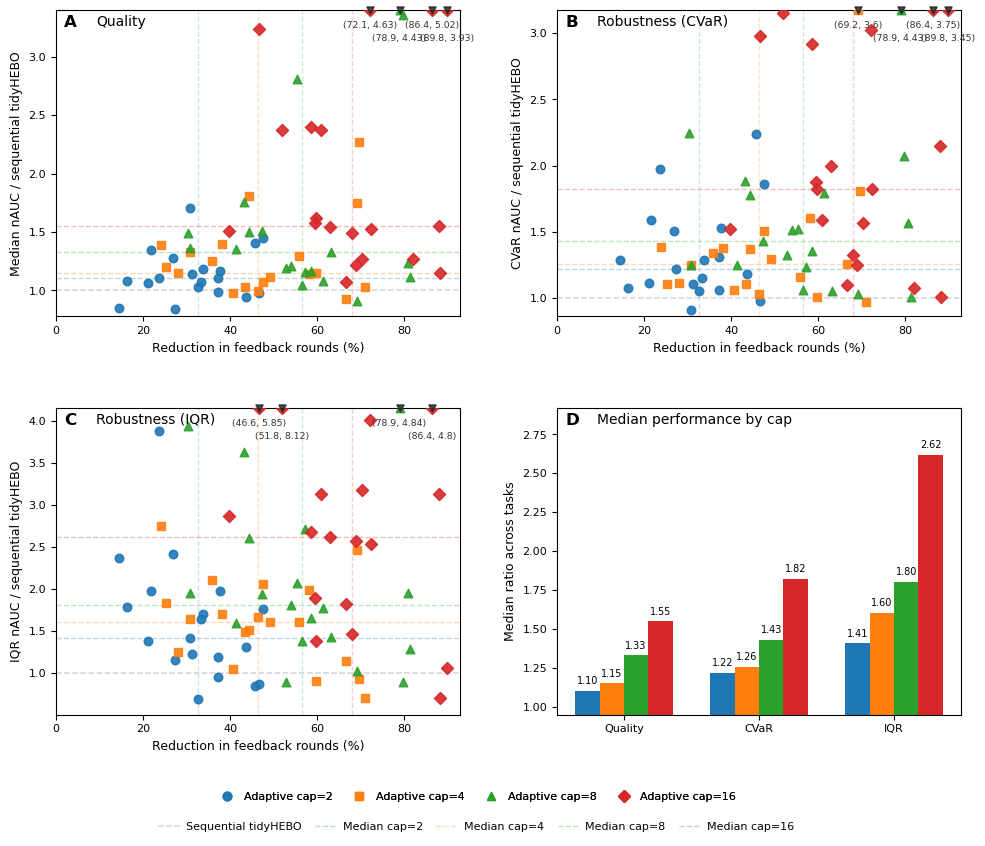

In [3]:
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd

CAPS = [2, 4, 8, 16]
CAP_MARKERS = {2: "o", 4: "s", 8: "^", 16: "D"}
CAP_COLORS = {2: "C0", 4: "C1", 8: "C2", 16: "C3"}

METRICS = [
    ("median_ratio", "Quality", "Median nAUC / sequential tidyHEBO", "A"),
    ("CVaR_ratio", "Robustness (CVaR)", "CVaR nAUC / sequential tidyHEBO", "B"),
    ("IQR_ratio", "Robustness (IQR)", "IQR nAUC / sequential tidyHEBO", "C"),
]


def _normalize_task_level(df):
    """Normalise the column names produced by ``build_adaptive_summary``
    so that the plotting helpers below can rely on the same schema used
    by the original ``make_adaptive_batching_points_only`` script."""
    df = df.copy()

    if "task" not in df.columns:
        raise ValueError("task_level is missing a 'task' column")
    if "cap" not in df.columns:
        raise ValueError("task_level is missing a 'cap' column")
    df["cap"] = df["cap"].astype(int)

    savings_candidates = [
        "round_savings_pct",
        "feedback_reduction",
        "feedback_reduction_pct",
        "median_feedback_reduction",
    ]
    for column in savings_candidates:
        if column in df.columns:
            df["round_savings_pct"] = df[column].astype(float)
            break
    else:
        raise ValueError(
            "No feedback-reduction column found in task_level; "
            "expected one of " + ", ".join(savings_candidates)
        )

    # The saved per-task savings may be a fraction (0–1) or a percentage (0–100).
    if df["round_savings_pct"].max() <= 1.5:
        df["round_savings_pct"] = df["round_savings_pct"] * 100.0

    ratio_candidates = {
        "median_ratio": ["median_ratio", "median_nAUC_ratio"],
        "CVaR_ratio": ["CVaR_ratio", "CVaR_nAUC_ratio"],
        "IQR_ratio": ["IQR_ratio", "IQR_nAUC_ratio"],
    }
    for target, candidates in ratio_candidates.items():
        for column in candidates:
            if column in df.columns:
                df[target] = df[column].astype(float)
                break
        else:
            raise ValueError(
                f"No column found for {target}; expected one of "
                + ", ".join(candidates)
            )

    return df


def _robust_ylim(values, lower_q=0.03, upper_q=0.94):
    values = np.asarray(values, dtype=float)
    lo = np.quantile(values, lower_q)
    hi = np.quantile(values, upper_q)
    span = max(hi - lo, 0.20)
    return float(min(0.95, lo - 0.06 * span)), float(hi + 0.06 * span)


def _format_offscale_coordinate(x, y):
    return f"({x:.1f}, {y:.3g})"


def _build_summary(df):
    rows = []
    for metric, *_ in METRICS:
        for cap in CAPS:
            g = df[df["cap"] == cap]
            rows.append(
                {
                    "metric": metric,
                    "cap": cap,
                    "median_round_savings_pct": float(
                        np.median(g["round_savings_pct"])
                    ),
                    "median_ratio": float(np.median(g[metric])),
                }
            )
    return pd.DataFrame(rows)


def _draw_scatter_panel(ax, df, summary, metric, title, ylabel, panel):
    med = summary[summary["metric"] == metric].sort_values("cap")

    all_y = np.r_[
        df[metric].astype(float).to_numpy(),
        [1.0],
        med["median_ratio"].to_numpy(),
    ]
    y_min, y_max = _robust_ylim(all_y)
    x_max = max(72.0, float(df["round_savings_pct"].max()) + 3.0)

    ax.axhline(
        1.0, color="0.50", alpha=0.35, linewidth=1.1, linestyle="--", zorder=0
    )

    for _, row in med.iterrows():
        cap = int(row["cap"])
        median_y = float(row["median_ratio"])
        median_x = float(row["median_round_savings_pct"])
        ax.axhline(
            median_y,
            color=CAP_COLORS[cap],
            alpha=0.30,
            linewidth=1.0,
            linestyle="--",
            zorder=0,
        )
        ax.axvline(
            median_x,
            color=CAP_COLORS[cap],
            alpha=0.22,
            linewidth=1.0,
            linestyle="--",
            zorder=0,
        )

    offscale = []
    for cap in CAPS:
        g = df[df["cap"] == cap]
        x = g["round_savings_pct"].astype(float).to_numpy()
        y = g[metric].astype(float).to_numpy()

        ax.scatter(
            x,
            np.minimum(y, y_max),
            s=38,
            marker=CAP_MARKERS[cap],
            color=CAP_COLORS[cap],
            alpha=0.90,
            zorder=3,
        )

        for task, xx, yy in zip(g["task"], x, y):
            if yy > y_max:
                offscale.append(
                    {"task": task, "cap": cap, "x": float(xx), "y": float(yy)}
                )

    offscale = sorted(offscale, key=lambda item: item["x"])
    for i, point in enumerate(offscale):
        ax.scatter(
            [point["x"]],
            [y_max],
            s=26,
            marker="v",
            color="0.15",
            alpha=0.85,
            zorder=5,
            clip_on=False,
        )
        ax.annotate(
            _format_offscale_coordinate(point["x"], point["y"]),
            (point["x"], y_max),
            xytext=(0, -8 - 9 * (i % 2)),
            textcoords="offset points",
            ha="center",
            va="top",
            fontsize=6.7,
            color="0.20",
            clip_on=False,
        )

    ax.set_xlim(0, x_max)
    ax.set_ylim(y_min, y_max)

    ax.text(
        0.02, 0.985, panel,
        transform=ax.transAxes, ha="left", va="top",
        fontsize=12, fontweight="bold",
    )
    ax.text(
        0.10, 0.985, title,
        transform=ax.transAxes, ha="left", va="top", fontsize=10,
    )
    ax.set_xlabel("Reduction in feedback rounds (%)", fontsize=9)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.tick_params(labelsize=8)


def _draw_panel_d(ax, summary):
    metric_labels = ["Quality", "CVaR", "IQR"]
    ratio_metrics = ["median_ratio", "CVaR_ratio", "IQR_ratio"]

    xpos = np.arange(len(metric_labels))
    width = 0.18

    ax.text(
        0.02, 0.985, "D",
        transform=ax.transAxes, ha="left", va="top",
        fontsize=12, fontweight="bold",
    )
    ax.text(
        0.10, 0.985, "Median performance by cap",
        transform=ax.transAxes, ha="left", va="top", fontsize=10,
    )

    max_value = 0.0
    for i, cap in enumerate(CAPS):
        values = [
            float(
                summary[
                    (summary["metric"] == metric) & (summary["cap"] == cap)
                ]["median_ratio"].iloc[0]
            )
            for metric in ratio_metrics
        ]

        bars = ax.bar(
            xpos + (i - 1.5) * width,
            values,
            width=width,
            color=CAP_COLORS[cap],
            label=f"cap={cap}",
        )
        max_value = max(max_value, max(values))

        for bar, value in zip(bars, values):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                value + 0.03,
                f"{value:.2f}",
                ha="center",
                va="bottom",
                fontsize=7,
            )

    ax.set_xticks(xpos)
    ax.set_xticklabels(metric_labels, fontsize=8)
    ax.set_ylabel("Median ratio across tasks", fontsize=9)
    ax.tick_params(labelsize=8)
    ax.set_ylim(0.95, max(2.8, max_value + 0.30))


def _marker_handles():
    return [
        Line2D(
            [0], [0],
            marker=CAP_MARKERS[cap],
            color=CAP_COLORS[cap],
            linestyle="None",
            markersize=6.2,
            label=f"Adaptive cap={cap}",
        )
        for cap in CAPS
    ]


def _dashed_handles():
    return [
        Line2D(
            [0], [0],
            color="0.50",
            linestyle="--",
            linewidth=1.1,
            alpha=0.35,
            label="Sequential tidyHEBO",
        ),
        *[
            Line2D(
                [0], [0],
                color=CAP_COLORS[cap],
                linestyle="--",
                linewidth=1.0,
                alpha=0.30,
                label=f"Median cap={cap}",
            )
            for cap in CAPS
        ],
    ]


def _add_two_row_legend(fig):
    first = fig.legend(
        handles=_marker_handles(),
        loc="lower center",
        ncol=4,
        frameon=False,
        fontsize=8,
        bbox_to_anchor=(0.5, 0.048),
        columnspacing=1.4,
        handletextpad=0.5,
    )
    fig.add_artist(first)

    fig.legend(
        handles=_dashed_handles(),
        loc="lower center",
        ncol=5,
        frameon=False,
        fontsize=8,
        bbox_to_anchor=(0.5, 0.014),
        columnspacing=1.2,
        handletextpad=0.5,
    )


def plot_adaptive_batching_figure(task_level):
    """Assemble the 2×2 manuscript figure from the per-task DataFrame."""
    df = _normalize_task_level(task_level)
    summary = _build_summary(df)

    fig = plt.figure(figsize=(10.0, 8.7))
    gs = fig.add_gridspec(2, 2, hspace=0.30, wspace=0.24)

    ax_a = fig.add_subplot(gs[0, 0])
    ax_b = fig.add_subplot(gs[0, 1])
    ax_c = fig.add_subplot(gs[1, 0])
    ax_d = fig.add_subplot(gs[1, 1])

    _draw_scatter_panel(ax_a, df, summary, *METRICS[0])
    _draw_scatter_panel(ax_b, df, summary, *METRICS[1])
    _draw_scatter_panel(ax_c, df, summary, *METRICS[2])
    _draw_panel_d(ax_d, summary)

    _add_two_row_legend(fig)

    fig.subplots_adjust(
        left=0.08,
        right=0.985,
        top=0.97,
        bottom=0.16,
        wspace=0.24,
        hspace=0.30,
    )

    return fig, (ax_a, ax_b, ax_c, ax_d)


fig, axes = plot_adaptive_batching_figure(task_level)
plt.show()